# TASK 5 · Sales Prediction Using Python

## Objective: 
Build a regression model that predicts product sales based on advertising spend across different media channels (TV, Radio, Newspaper).

## Step 0: Import Required Libraries & Load Dataset

### 0.1. Import Required Libraries

First, we import all the libraries needed for data manipulation, visualization, model training, and evaluation. Then we load the Advertising dataset into a pandas DataFrame.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### 0.2. Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/yasserh/advertising-sales-dataset/Advertising Budget and Sales.csv")

#Display the first rows
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Step 1: Data Loading & Exploratory Data Analysis (EDA)

Before building a model, we must understand the dataset:

+ Check its dimensions.
+ Inspect data types.
+ Detect missing values.
+ Compute descriptive statistics.
+ Visualize relationships between variables.

### 1.1. Dataset Shape

In [3]:
df.shape

(200, 5)

### 1.2. Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


### 1.3. Missing Values

In [5]:
df.isnull().sum()

Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

### 1.4. Descriptive Statistics

In [6]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


### 1.5. Removing the indexing column

"Unnamed" is not an advertising feature. It is simply an index column that was saved with the CSV file. If we keep it, the model may incorrectly treat it as a predictive feature.

In [7]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [8]:
#Verifying
df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### 1.6. Pairplot

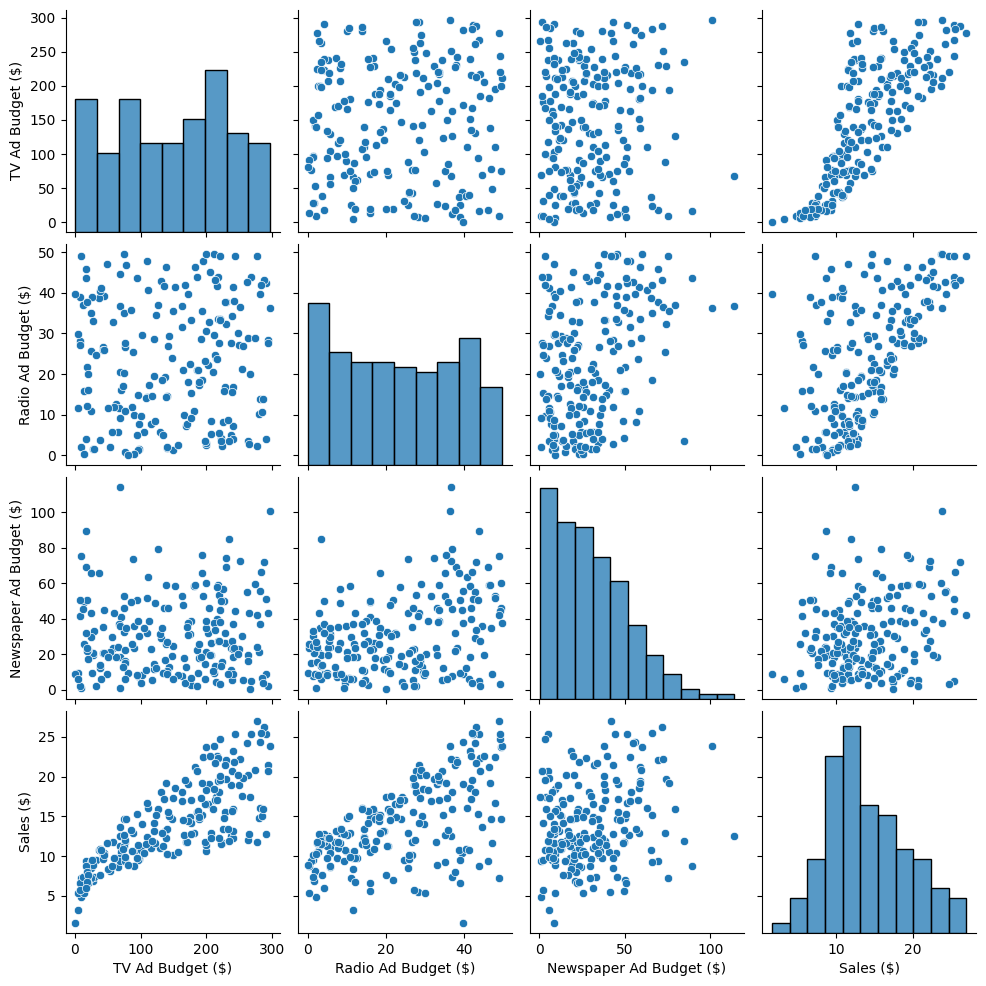

In [9]:
sns.pairplot(df)

plt.show()

### Observation

The dataset contains **200 observations** and **5 numerical columns** with **no missing values**. Advertising budgets vary considerably across the three media channels, while sales range from **1.6** to **27.0**, making the dataset suitable for regression analysis.


## Step 2: Individual Scatter Plots

Scatter plots allow us to visually examine the relationship between each advertising channel and product sales. Each point represents one observation in the dataset.

+ An upward trend suggests a positive relationship.
+ A downward trend suggests a negative relationship.
+ A random pattern indicates little or no relationship.

### 2.1. Sales vs. TV Advertising Budget

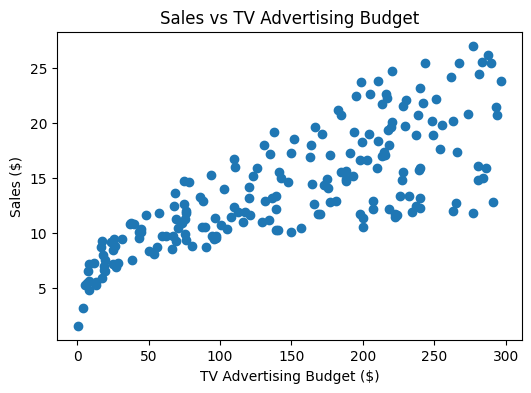

In [10]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["TV Ad Budget ($)"],
    df["Sales ($)"]
)

plt.title("Sales vs TV Advertising Budget")
plt.xlabel("TV Advertising Budget ($)")
plt.ylabel("Sales ($)")

plt.show()

### Observation

The scatter plot shows a clear positive relationship between TV advertising budget and sales. As TV advertising expenditure increases, sales generally tend to increase.

### 2.2. Sales vs. Radio Advertising Budget

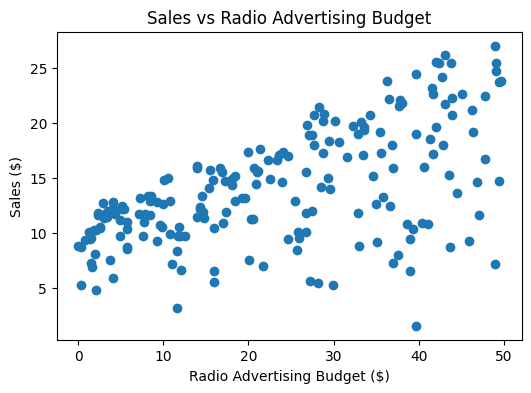

In [11]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["Radio Ad Budget ($)"],
    df["Sales ($)"]
)

plt.title("Sales vs Radio Advertising Budget")
plt.xlabel("Radio Advertising Budget ($)")
plt.ylabel("Sales ($)")

plt.show()

### Observation

The scatter plot indicates a positive relationship between radio advertising budget and sales, although the points exhibit greater variability than for TV advertising.

### 2.3. Sales vs. Newspaper Advertising Budget

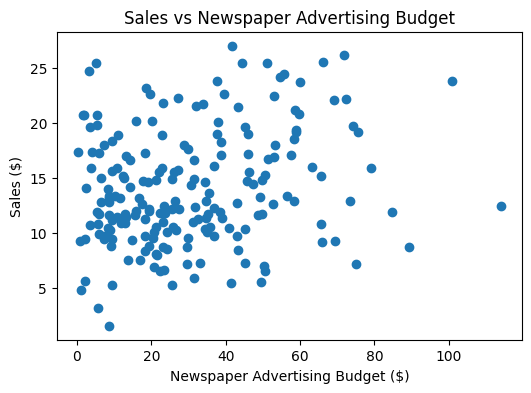

In [12]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["Newspaper Ad Budget ($)"],
    df["Sales ($)"]
)

plt.title("Sales vs Newspaper Advertising Budget")
plt.xlabel("Newspaper Advertising Budget ($)")
plt.ylabel("Sales ($)")

plt.show()

### Observation

The relationship between newspaper advertising budget and sales appears weaker, with points more widely dispersed and no clear linear trend.

## Step 3: Correlation Matrix Heatmap

A correlation matrix measures the strength and direction of the linear relationship between numerical variables. The correlation coefficient ranges from:

* +1: Perfect positive correlation
* 0 : No linear correlation
* −1: Perfect negative correlation

It helps identify which advertising channels are most strongly associated with sales.

### 3.1. Compute the Correlation Matrix

In [13]:
correlation_matrix = df.corr()

correlation_matrix

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
TV Ad Budget ($),1.000000,0.054809,0.056648,0.782224
Radio Ad Budget ($),0.054809,1.000000,0.354104,0.576223
Newspaper Ad Budget ($),0.056648,0.354104,1.000000,0.228299
Sales ($),0.782224,0.576223,0.228299,1.000000


### 3.2. Plot the Heatmap

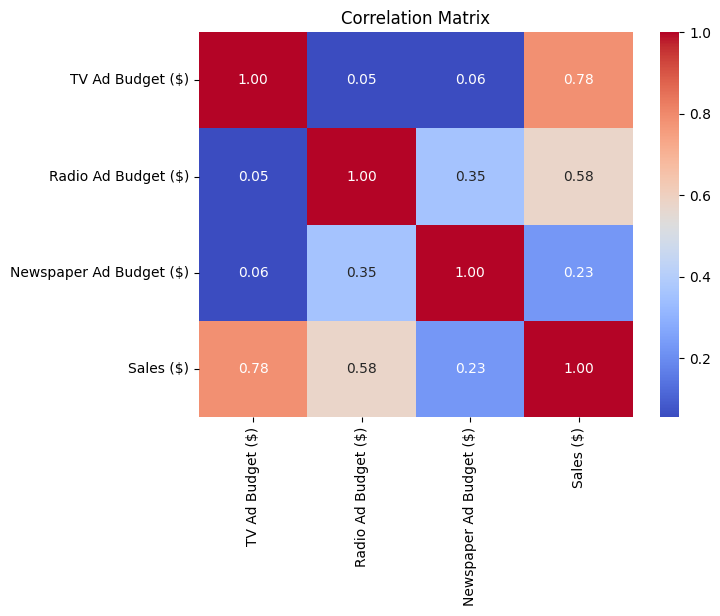

In [14]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Observation

The correlation analysis indicates that TV advertising has the strongest relationship with sales (r = 0.78), followed by radio advertising (r = 0.58). Newspaper advertising shows a weaker correlation with sales (r = 0.23).

## Step 4: Train/Test Split

### 4.1. Define Features and Target

In [15]:
#Features: input variables (advertising investments)
X = df[
    [
        "TV Ad Budget ($)",
        "Radio Ad Budget ($)",
        "Newspaper Ad Budget ($)"
    ]
]

#Target: the value we want to predict (sales)
y = df["Sales ($)"]

### 4.2. Split the Dataset

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42 # Ensures that the same split is obtained every time the notebook is executed, making results reproducible.
)

### 4.3. Verify the Split

In [17]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (160, 3)
X_test: (40, 3)
y_train: (160,)
y_test: (40,)


## Step 5: Train a Linear Regression Model (Baseline)

Linear Regression is used as the baseline model because it is simple, interpretable, and assumes a linear relationship between advertising budgets and sales.

### 5.1. Create the Model

In [18]:
lr_model = LinearRegression()

### 5.2. Train the Model

In [19]:
lr_model.fit(
    X_train,
    y_train
)

LinearRegression()

### 5.3. Generate Predictions

In [20]:
y_pred_lr = lr_model.predict(
    X_test
)

### 5.4. Check Predictions

This compares the real sales values with the model predictions.

In [21]:
comparison = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred_lr
})

comparison.head()

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373


## Step 6: Train Additional Regression Models

We train two additional regression models to compare the baseline model with more advanced ensemble methods, we train:

**1. Random Forest Regressor:** Ensemble model capable of learning non-linear relationships.

**2. Gradient Boosting Regressor:** Sequential ensemble model that improves predictions by correcting previous errors.

### 6.1. Random Forest Regressor

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

### 6.2. Gradient Boosting Regressor

In [24]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

### 6.3. Verify Predictions

In [25]:
print("Random Forest Predictions:")
print(y_pred_rf[:5])

print()

print("Gradient Boosting Predictions:")
print(y_pred_gb[:5])

Random Forest Predictions:
[17.698 21.804 20.628  6.793 22.927]

Gradient Boosting Predictions:
[17.4193688  21.75323977 20.26621166  6.51567214 23.61986725]


## Step7: Evaluate the Regression Models

To compare the predictive performance of the three regression models, we evaluate them using:

* **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual sales. Lower values indicate better performance.

* **RMSE (Root Mean Squared Error)**: Measures the average prediction error while penalizing larger errors more heavily. Lower values indicate better performance.

* **R² Score (Coefficient of Determination):** Indicates the proportion of variance in sales explained by the model. Values closer to 1 indicate better predictive performance.

### 7.1. Evaluate All Models

In [26]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    "R²": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284
2,Gradient Boosting,0.618742,0.729782,0.983127


### Observation

Among the three models, **Gradient Boosting** achieved the best performance with the **lowest MAE (0.619)**, the **lowest RMSE (0.730)**, and the **highest R² score (0.983)**. This indicates that it provides the most accurate sales predictions on the test dataset, followed closely by Random Forest, while Linear Regression showed comparatively lower predictive performance.

## Step 8: Residual Plot for the Best Model

A residual plot is used to analyze the prediction errors of the best-performing model (Gradient Boosting).

The residual is calculated as:
                 
 **Residual= Actual Sales−Predicted Sales**  

A good regression model should have:

* Residuals randomly distributed around 0: no systematic error.
* No visible pattern or trend: model captures the relationship correctly.

### 8.1. Calculate Residuals

In [27]:
residuals = y_test - y_pred_gb

### 8.2. Plot Residuals

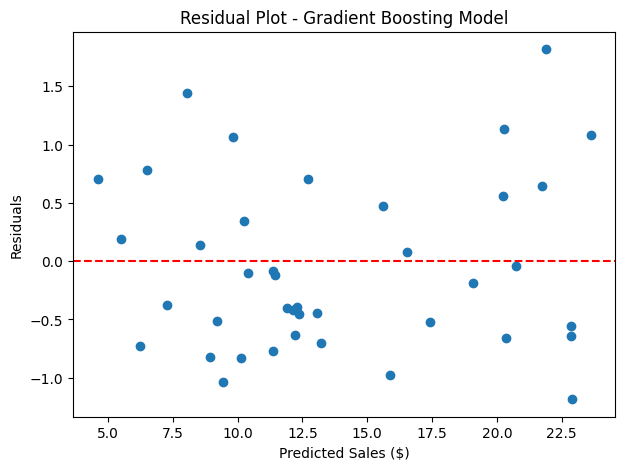

In [28]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_pred_gb,
    residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot - Gradient Boosting Model")
plt.xlabel("Predicted Sales ($)")
plt.ylabel("Residuals")

plt.show()

### Observation

The residual plot shows that prediction errors are randomly distributed around zero without a clear pattern. This indicates that the Gradient Boosting model captures the relationship between advertising budgets and sales effectively, with no significant systematic bias.

## Step 10: Interpretation (Advertising Channel Impact on Sales)

The goal is to determine which advertising channel contributes the most to sales prediction.

Since Gradient Boosting achieved the best performance (R² = 0.983), feature importance is used to measure the contribution of each advertising channel. A higher importance value indicates a greater influence on the model's sales predictions.

### 10.1. Extract Feature Importance

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,TV Ad Budget ($),0.612579
1,Radio Ad Budget ($),0.380914
2,Newspaper Ad Budget ($),0.006507


### 10.2. Visualize Feature Impact

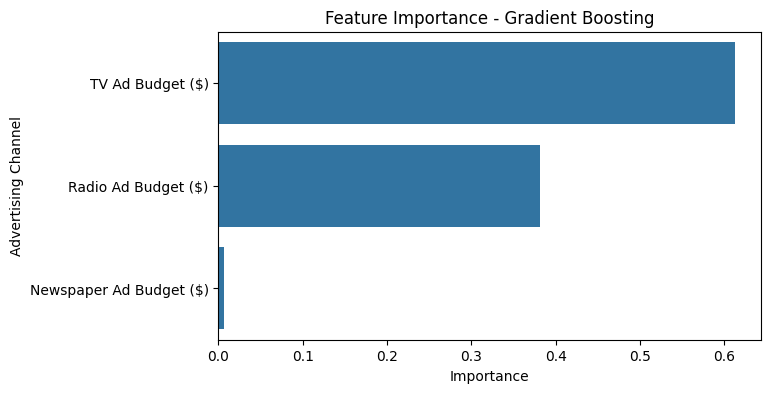

In [35]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

### Observation
The feature importance analysis shows that TV advertising has the greatest impact on sales (61.26%), followed by Radio advertising (38.09%). Newspaper advertising has a negligible influence (0.65%), indicating that it contributes very little to the model's sales predictions.

## References

- **Dataset:** Advertising Sales Prediction dataset (`Advertising.csv`) from Kaggle.
- **Documentation:** Scikit-learn documentation for `LinearRegression`, `RandomForestRegressor`, `GradientBoostingRegressor`, and regression evaluation metrics (MAE, RMSE, and R²).
- **Learning Resources:** Python tutorials on advertising sales prediction and regression modeling available on YouTube.